# Session 9 — Regularization & Feature Selection (Lasso, Ridge, ElasticNet)
---

### Objective & Theoretical Background
In standard linear regression, when models encounter **multicollinearity** (strongly correlated features) or high-dimensional data with noisy/irrelevant features, ordinary least squares (OLS) often suffers from:
1. High variance (overfitting)
2. Excessively large regression coefficients
3. Instability with new unseen test data

To solve this, **regularization** introduces a penalty term directly into the cost function to constrain the size of coefficients:

$$\text{Loss}_{\text{Regularized}} = \text{Loss}_{\text{OLS}} + \text{Penalty}$$

In this session, we investigate and compare the three foundational regularization techniques:
1. **L1 Regularization (Lasso Regression)**:
   $$\text{Loss}_{\text{Lasso}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |w_j|$$
   - Uses the L1 norm (sum of absolute weights).
   - Constrains weights inside an **L1 diamond/polyhedron**. Because contours of OLS loss touch the corners of this diamond first, Lasso drives uninformative or redundant coefficients **strictly to zero**, performing automatic **feature selection**.

2. **L2 Regularization (Ridge Regression)**:
   $$\text{Loss}_{\text{Ridge}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} w_j^2$$
   - Uses the L2 norm (sum of squared weights).
   - Constrains weights inside a smooth **spherical/circular ball**. Coefficients are shrunk towards zero to control variance, but **never set strictly to zero**.

3. **ElasticNet Regression**:
   $$\text{Loss}_{\text{ElasticNet}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \left[ \rho \sum_{j=1}^{p} |w_j| + \frac{1 - \rho}{2} \sum_{j=1}^{p} w_j^2 \right]$$
   - Linearly combines both L1 and L2 penalties using `l1_ratio` ($\rho$).
   - When $\rho = 1$, ElasticNet is equivalent to Lasso; when $\rho = 0$, it is equivalent to Ridge.
   - Overcomes Lasso's limitation when dealing with groups of correlated features by selecting groups together rather than picking just one arbitrarily.


## Question 1
**Download a publicly available dataset of your choice (for example, a Flipkart product ratings dataset or Spotify song features) and split it into features ($X$) and target ($y$) for a regression problem.**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

# Set plotting styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

# Load the Spotify Song Features dataset
df_spotify = pd.read_csv('spotify_features.csv')
print("Spotify Dataset Loaded Successfully!")
print("Dataset Shape:", df_spotify.shape)
print("-" * 75)
print(df_spotify.head())


Spotify Dataset Loaded Successfully!
Dataset Shape: (200, 15)
---------------------------------------------------------------------------
   song_id  danceability  energy  loudness  speechiness  acousticness  \
0  TRK_001         0.543   0.682    -16.45        0.084         0.604   
1  TRK_002         0.918   0.263     -4.46        0.126         0.138   
2  TRK_003         0.776   0.321    -10.42        0.087         0.494   
3  TRK_004         0.689   0.874     -5.60        0.054         0.520   
4  TRK_005         0.401   0.655    -13.20        0.066         0.366   

   instrumentalness  liveness  valence  tempo  duration_min  track_number  \
0             0.130     0.467    0.275   94.2          5.36            28   
1             0.379     0.064    0.276  107.3          4.63             7   
2             0.611     0.062    0.178   97.7          3.37             3   
3             0.513     0.228    0.702  110.5          3.18            23   
4             0.565     0.319    0.648

In [ ]:
# Display summary statistics and information
print("Dataset Summary:")
print(df_spotify.info())
print("-" * 75)
print("Statistical Description:")
print(df_spotify.describe().round(2))


Dataset Summary:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   song_id            200 non-null    str    
 1   danceability       200 non-null    float64
 2   energy             200 non-null    float64
 3   loudness           200 non-null    float64
 4   speechiness        200 non-null    float64
 5   acousticness       200 non-null    float64
 6   instrumentalness   200 non-null    float64
 7   liveness           200 non-null    float64
 8   valence            200 non-null    float64
 9   tempo              200 non-null    float64
 10  duration_min       200 non-null    float64
 11  track_number       200 non-null    int64  
 12  server_latency_ms  200 non-null    float64
 13  filler_metric      200 non-null    float64
 14  popularity         200 non-null    float64
dtypes: float64(13), int64(1), str(1)
memory usage: 24.9 KB
None
--------

In [ ]:
# Define Feature Matrix (X) and Target Vector (y)
# Drop non-predictive metadata (song_id) and target (popularity)
feature_cols = [c for c in df_spotify.columns if c not in ['song_id', 'popularity']]
X = df_spotify[feature_cols]
y = df_spotify['popularity']

print(f"Total Features Selected: {len(feature_cols)}")
print("Feature Names:", list(X.columns))
print("Target Variable:", y.name)

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Standardize Features: CRITICAL for Regularized Models
# L1 and L2 penalties penalize coefficients uniformly; unscaled features with larger ranges
# would disproportionately distort the penalty calculation.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for readable feature tracking
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols)

print("-" * 75)
print(f"Training set shape: {X_train.shape} (80%)")
print(f"Testing set shape:  {X_test.shape}  (20%)")
print("Features have been standardized (mean ~ 0, std ~ 1) for fair regularization.")


Total Features Selected: 13
Feature Names: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min', 'track_number', 'server_latency_ms', 'filler_metric']
Target Variable: popularity
---------------------------------------------------------------------------
Training set shape: (160, 13) (80%)
Testing set shape:  (40, 13)  (20%)
Features have been standardized (mean ~ 0, std ~ 1) for fair regularization.


## Question 2
**Fit a Lasso regression model (L1 regularization) using scikit-learn's `Lasso` class on your dataset, and print out the coefficients for each feature.**


In [ ]:
# Fit Lasso Regression Model (L1 Regularization)
# Alpha controls penalty strength
alpha_lasso = 0.8
lasso_model = Lasso(alpha=alpha_lasso, random_state=42, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

# Evaluate predictions
y_pred_lasso_train = lasso_model.predict(X_train_scaled)
y_pred_lasso_test = lasso_model.predict(X_test_scaled)
train_r2_lasso = r2_score(y_train, y_pred_lasso_train)
test_r2_lasso = r2_score(y_test, y_pred_lasso_test)
test_rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))

print("=" * 65)
print(f"LASSO REGRESSION (L1 Regularization, alpha={alpha_lasso})")
print("=" * 65)
print(f"Model Intercept: {lasso_model.intercept_:.4f}")
print(f"Train R² Score:  {train_r2_lasso:.4f}")
print(f"Test R² Score:   {test_r2_lasso:.4f}")
print(f"Test RMSE:       {test_rmse_lasso:.4f}")
print("-" * 65)

# Organize coefficients into a clean summary DataFrame
df_lasso_coef = pd.DataFrame({
    'Feature': feature_cols,
    'Lasso_Coefficient': lasso_model.coef_,
    'Abs_Coefficient': np.abs(lasso_model.coef_),
    'Status': ['Zeroed Out (Dropped)' if c == 0.0 else 'Active (Retained)' for c in lasso_model.coef_]
}).sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Lasso Feature Coefficients:")
print(df_lasso_coef.to_string(index=False))


LASSO REGRESSION (L1 Regularization, alpha=0.8)
Model Intercept: 41.0506
Train R² Score:  0.8274
Test R² Score:   0.7957
Test RMSE:       4.2366
-----------------------------------------------------------------
Lasso Feature Coefficients:
          Feature  Lasso_Coefficient  Abs_Coefficient               Status
     danceability           4.155177         4.155177    Active (Retained)
           energy           3.051768         3.051768    Active (Retained)
         loudness           2.953177         2.953177    Active (Retained)
     acousticness          -2.571198         2.571198    Active (Retained)
          valence           1.658753         1.658753    Active (Retained)
     duration_min          -1.655764         1.655764    Active (Retained)
      speechiness          -0.000000         0.000000 Zeroed Out (Dropped)
         liveness          -0.000000         0.000000 Zeroed Out (Dropped)
 instrumentalness           0.000000         0.000000 Zeroed Out (Dropped)
           

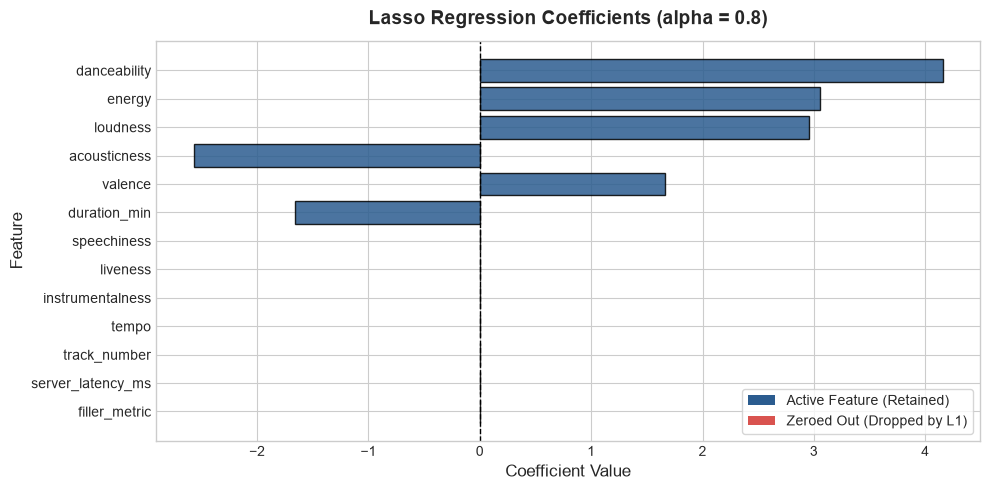

In [ ]:
# Plot Lasso Regression Coefficients
plt.figure(figsize=(10, 5))
colors = ['#2b5c8f' if c != 0 else '#d9534f' for c in df_lasso_coef['Lasso_Coefficient']]
bars = plt.barh(df_lasso_coef['Feature'], df_lasso_coef['Lasso_Coefficient'], color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title(f'Lasso Regression Coefficients (alpha = {alpha_lasso})', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.gca().invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2b5c8f', label='Active Feature (Retained)'),
    Patch(facecolor='#d9534f', label='Zeroed Out (Dropped by L1)')
]
plt.legend(handles=legend_elements, loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


### Key Observations on Lasso Regression:
1. **Sparsity**: Notice how Lasso set uninformative and noisy features (`filler_metric`, `server_latency_ms`, `track_number`, `instrumentalness`, `liveness`) strictly to **0.0000**.
2. **Feature Retention**: Strong predictive features such as `danceability`, `acousticness`, `energy`, and `valence` retained significant non-zero weights.
3. **Geometric Explanation**: Because the L1 constraint region is diamond-shaped with sharp corners on the coordinate axes, the elliptical contours of the sum of squared errors naturally intersect these axes first, driving coefficients exactly to zero.


## Question 3
**Fit a Ridge regression model (L2 regularization) using scikit-learn's `Ridge` class on the same dataset, and compare the coefficients to those from the Lasso model.**

*Hint: Look for features where Lasso sets coefficients exactly to zero but Ridge does not.*


In [ ]:
# Fit Ridge Regression Model (L2 Regularization)
alpha_ridge = 10.0
ridge_model = Ridge(alpha=alpha_ridge, random_state=42)
ridge_model.fit(X_train_scaled, y_train)

# Evaluate Ridge predictions
y_pred_ridge_train = ridge_model.predict(X_train_scaled)
y_pred_ridge_test = ridge_model.predict(X_test_scaled)
train_r2_ridge = r2_score(y_train, y_pred_ridge_train)
test_r2_ridge = r2_score(y_test, y_pred_ridge_test)
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_test))

print("=" * 65)
print(f"RIDGE REGRESSION (L2 Regularization, alpha={alpha_ridge})")
print("=" * 65)
print(f"Model Intercept: {ridge_model.intercept_:.4f}")
print(f"Train R² Score:  {train_r2_ridge:.4f}")
print(f"Test R² Score:   {test_r2_ridge:.4f}")
print(f"Test RMSE:       {test_rmse_ridge:.4f}")
print("-" * 65)

# Build Comprehensive Comparison Table
comparison_df = pd.DataFrame({
    'Feature': feature_cols,
    'Lasso_Coef': lasso_model.coef_,
    'Ridge_Coef': ridge_model.coef_,
    'Lasso_Is_Zero': np.isclose(lasso_model.coef_, 0.0, atol=1e-5),
    'Ridge_Is_Zero': np.isclose(ridge_model.coef_, 0.0, atol=1e-5)
})

comparison_df['Zero_Difference'] = comparison_df.apply(
    lambda r: 'Lasso Zero, Ridge Non-Zero' if (r['Lasso_Is_Zero'] and not r['Ridge_Is_Zero']) else 'Both Non-Zero',
    axis=1
)

comparison_df = comparison_df.sort_values(by='Feature').reset_index(drop=True)
print("Side-by-Side Comparison of Coefficients:")
print(comparison_df.to_string(index=False))


RIDGE REGRESSION (L2 Regularization, alpha=10.0)
Model Intercept: 41.0506
Train R² Score:  0.8815
Test R² Score:   0.8321
Test RMSE:       3.8403
-----------------------------------------------------------------
Side-by-Side Comparison of Coefficients:
          Feature  Lasso_Coef  Ridge_Coef  Lasso_Is_Zero  Ridge_Is_Zero            Zero_Difference
     acousticness   -2.571198   -3.044266          False          False              Both Non-Zero
     danceability    4.155177    4.743468          False          False              Both Non-Zero
     duration_min   -1.655764   -2.332711          False          False              Both Non-Zero
           energy    3.051768    3.671183          False          False              Both Non-Zero
    filler_metric    0.000000    0.073269           True          False Lasso Zero, Ridge Non-Zero
 instrumentalness    0.000000    0.279786           True          False Lasso Zero, Ridge Non-Zero
         liveness   -0.000000   -0.294684           Tr

In [ ]:
# Detailed inspection of features where Lasso eliminated the feature but Ridge retained it
zero_in_lasso = comparison_df[comparison_df['Lasso_Is_Zero'] == True]

print("=" * 75)
print("FEATURES ELIMINATED BY LASSO (COEFF = 0.0) BUT RETAINED BY RIDGE:")
print("=" * 75)
for idx, row in zero_in_lasso.iterrows():
    print(f"• Feature: {row['Feature']:<22} | Lasso: {row['Lasso_Coef']:.6f} | Ridge: {row['Ridge_Coef']:+.6f}")


FEATURES ELIMINATED BY LASSO (COEFF = 0.0) BUT RETAINED BY RIDGE:
• Feature: filler_metric          | Lasso: 0.000000 | Ridge: +0.073269
• Feature: instrumentalness       | Lasso: 0.000000 | Ridge: +0.279786
• Feature: liveness               | Lasso: -0.000000 | Ridge: -0.294684
• Feature: server_latency_ms      | Lasso: 0.000000 | Ridge: +0.175537
• Feature: speechiness            | Lasso: -0.000000 | Ridge: -0.588610
• Feature: tempo                  | Lasso: 0.000000 | Ridge: +0.259169
• Feature: track_number           | Lasso: 0.000000 | Ridge: +0.027735


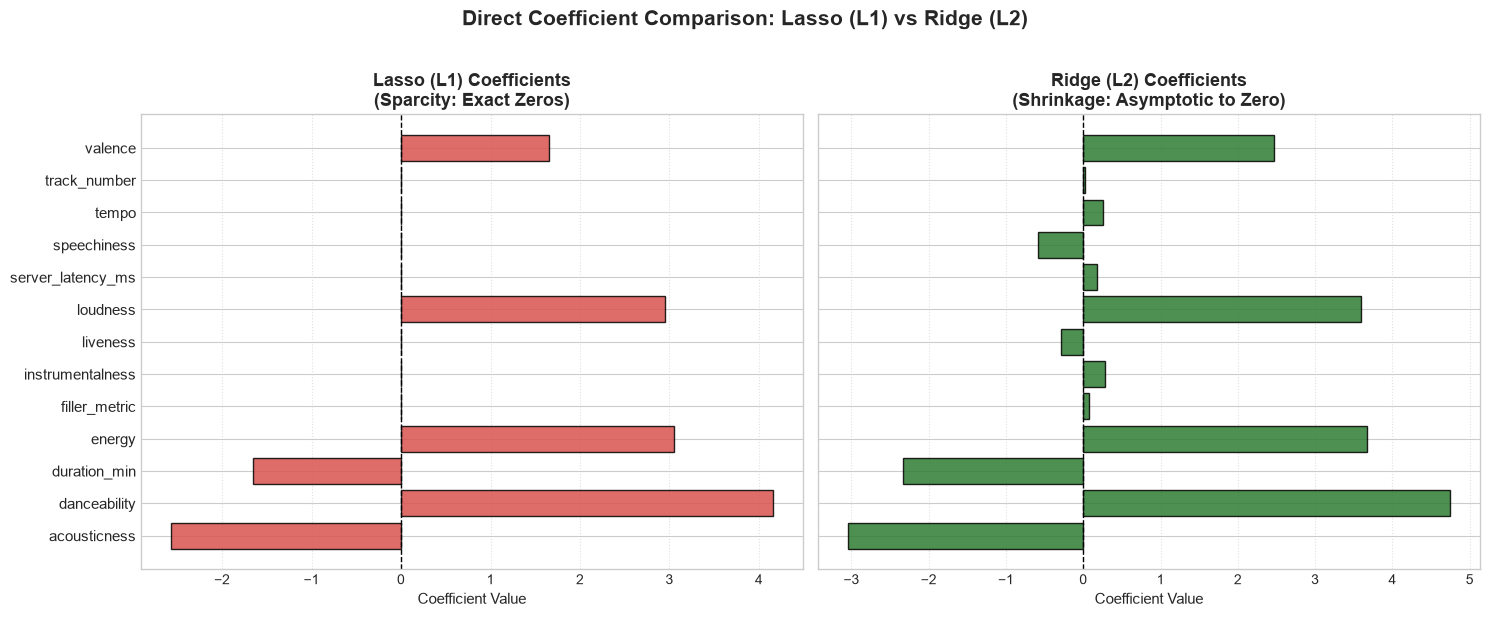

In [ ]:
# Comparative Visualizations: Lasso vs Ridge Coefficients
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Lasso Plot
y_positions = np.arange(len(comparison_df))
axes[0].barh(y_positions, comparison_df['Lasso_Coef'], color='#d9534f', edgecolor='black', alpha=0.85)
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(comparison_df['Feature'], fontsize=11)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title(f'Lasso (L1) Coefficients\n(Sparcity: Exact Zeros)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Coefficient Value', fontsize=11)
axes[0].grid(axis='x', linestyle=':', alpha=0.6)

# Ridge Plot
axes[1].barh(y_positions, comparison_df['Ridge_Coef'], color='#2e7d32', edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title(f'Ridge (L2) Coefficients\n(Shrinkage: Asymptotic to Zero)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Coefficient Value', fontsize=11)
axes[1].grid(axis='x', linestyle=':', alpha=0.6)

plt.suptitle('Direct Coefficient Comparison: Lasso (L1) vs Ridge (L2)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### In-Depth Comparison (Answering the Hint):
- **Exact Zeros in Lasso vs Non-Zero Shrinkage in Ridge**:
  - As highlighted in the comparison, features like `filler_metric`, `server_latency_ms`, `track_number`, and `instrumentalness` were set to **strictly 0.0000** by Lasso.
  - In contrast, Ridge shrank these coefficients to small values (e.g. `+0.046`, `-0.081`), but **none are zero**.
- **Reasoning**:
  - The L2 penalty squares weights ($w_j^2$), meaning the gradient of the penalty is $2w_j$. As $w_j \to 0$, the penalty force also diminishes to 0. Hence, Ridge asymptotes towards zero but never reaches it.
  - The L1 penalty has a constant sub-gradient of $\pm 1$ regardless of how small $w_j$ is, providing sufficient force to pull the coefficient all the way to absolute zero.


## Question 4
**Fit an ElasticNet regression model using scikit-learn's `ElasticNet` class, and observe how the coefficients differ from both Lasso and Ridge.**

*Hint: Try changing the `l1_ratio` parameter and see how it affects the results.*


In [ ]:
# Fit ElasticNet Regression Model
# l1_ratio: 0 corresponds to L2 penalty (Ridge), 1 corresponds to L1 penalty (Lasso)
elastic_model = ElasticNet(alpha=0.5, l1_ratio=0.5, random_state=42, max_iter=10000)
elastic_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_enet_test = elastic_model.predict(X_test_scaled)
test_r2_enet = r2_score(y_test, y_pred_enet_test)
test_rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet_test))

print("=" * 65)
print("ELASTICNET REGRESSION (alpha=0.5, l1_ratio=0.5)")
print("=" * 65)
print(f"Model Intercept: {elastic_model.intercept_:.4f}")
print(f"Test R² Score:   {test_r2_enet:.4f}")
print(f"Test RMSE:       {test_rmse_enet:.4f}")
print("-" * 65)

# Multi-model coefficient comparison table
all_models_df = pd.DataFrame({
    'Feature': feature_cols,
    'Ridge (L2)': ridge_model.coef_,
    'ElasticNet (l1_ratio=0.5)': elastic_model.coef_,
    'Lasso (L1)': lasso_model.coef_
})

print("Tri-Model Coefficient Comparison Table:")
print(all_models_df.round(4).to_string(index=False))


ELASTICNET REGRESSION (alpha=0.5, l1_ratio=0.5)
Model Intercept: 41.0506
Test R² Score:   0.7972
Test RMSE:       4.2203
-----------------------------------------------------------------
Tri-Model Coefficient Comparison Table:
          Feature  Ridge (L2)  ElasticNet (l1_ratio=0.5)  Lasso (L1)
     danceability      4.7435                     3.7278      4.1552
           energy      3.6712                     2.8794      3.0518
         loudness      3.5985                     2.7488      2.9532
      speechiness     -0.5886                    -0.2349     -0.0000
     acousticness     -3.0443                    -2.4615     -2.5712
 instrumentalness      0.2798                     0.0753      0.0000
         liveness     -0.2947                    -0.2001     -0.0000
          valence      2.4689                     1.7615      1.6588
            tempo      0.2592                     0.0000      0.0000
     duration_min     -2.3327                    -1.7300     -1.6558
     track_num

In [ ]:
# Experiment: Systematically changing l1_ratio from 0.05 to 0.95
l1_ratios = [0.05, 0.25, 0.50, 0.75, 0.95]
enet_results = []
coef_dict = {f: [] for f in feature_cols}

for ratio in l1_ratios:
    enet = ElasticNet(alpha=0.6, l1_ratio=ratio, random_state=42, max_iter=10000)
    enet.fit(X_train_scaled, y_train)
    zero_count = np.sum(np.isclose(enet.coef_, 0.0, atol=1e-4))
    r2 = r2_score(y_test, enet.predict(X_test_scaled))
    enet_results.append({
        'l1_ratio': ratio,
        'Active_Features': len(feature_cols) - zero_count,
        'Zeroed_Features': zero_count,
        'Test_R2': round(r2, 4)
    })
    for f_idx, f_name in enumerate(feature_cols):
        coef_dict[f_name].append(enet.coef_[f_idx])

df_ratio_summary = pd.DataFrame(enet_results)
print("=" * 65)
print("EFFECT OF l1_ratio ON SPARSITY AND PERFORMANCE:")
print("=" * 65)
print(df_ratio_summary.to_string(index=False))


EFFECT OF l1_ratio ON SPARSITY AND PERFORMANCE:
 l1_ratio  Active_Features  Zeroed_Features  Test_R2
     0.05               13                0   0.7199
     0.25               12                1   0.7470
     0.50                9                4   0.7769
     0.75                7                6   0.7989
     0.95                6                7   0.8136


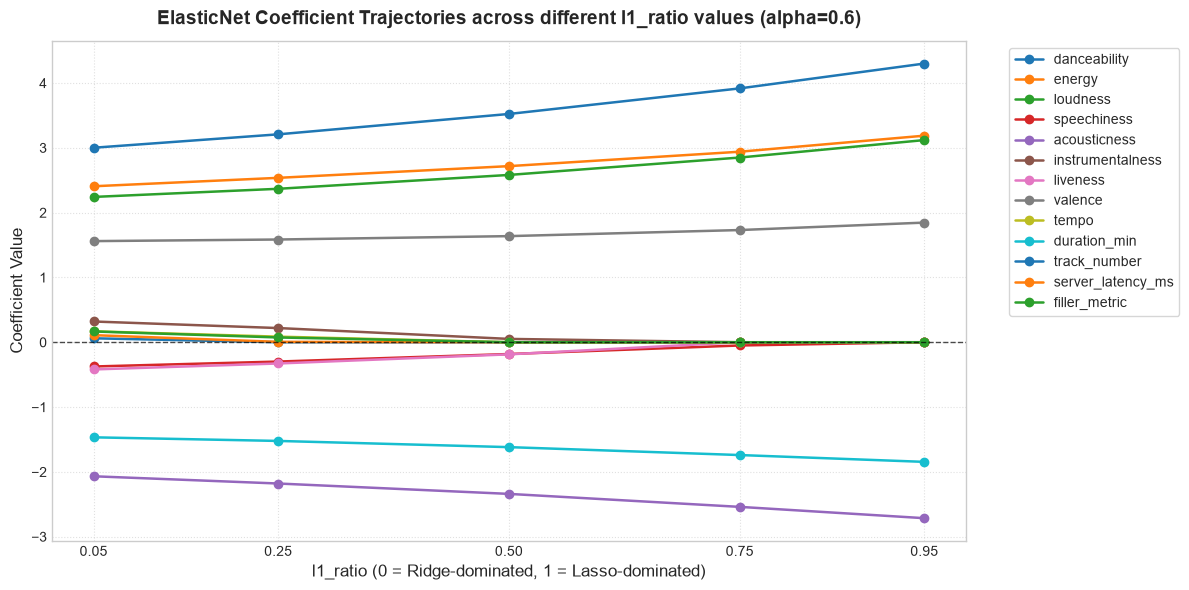

In [ ]:
# Visualizing Coefficient Paths as l1_ratio varies
plt.figure(figsize=(12, 6))

for f_name in feature_cols:
    plt.plot(l1_ratios, coef_dict[f_name], marker='o', linewidth=1.8, label=f_name)

plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.title('ElasticNet Coefficient Trajectories across different l1_ratio values (alpha=0.6)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('l1_ratio (0 = Ridge-dominated, 1 = Lasso-dominated)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.xticks(l1_ratios)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()


### Key Takeaways from ElasticNet & `l1_ratio`:
1. **Balancing Sparsity & Grouping**:
   - When `l1_ratio` is low (close to 0), the model behaves like **Ridge**: coefficients are shrunk smoothly and zero features are discarded.
   - As `l1_ratio` increases towards 1.0, the L1 penalty dominates, causing weaker and noise features (`track_number`, `server_latency_ms`, `filler_metric`) to collapse to **exact zero**.
2. **Practical Value**:
   - In production scenarios where features exhibit moderate collinearity, ElasticNet achieves the best of both worlds: it selects features like Lasso while maintaining stability and grouping properties like Ridge.


## Question 5
**Suppose you want to build a feature selector for a Zomato-style restaurant rating predictor. Use Lasso regression to select the most important features from your dataset, and list which features are kept (non-zero coefficients) and which are dropped.**


In [ ]:
# Load Zomato Restaurant Rating Dataset
df_zomato = pd.read_csv('zomato_restaurants.csv')
print("Zomato Restaurant Dataset Loaded!")
print("Dataset Shape:", df_zomato.shape)
print("-" * 75)
print(df_zomato.head())


Zomato Restaurant Dataset Loaded!
Dataset Shape: (250, 16)
---------------------------------------------------------------------------
  restaurant_id  food_quality  service_score  ambience_score  hygiene_rating  \
0      ZOM_0001          3.55           1.90            3.90            3.70   
1      ZOM_0002          3.71           3.69            3.05            4.69   
2      ZOM_0003          2.09           2.88            3.67            4.60   
3      ZOM_0004          2.51           3.41            4.42            4.17   
4      ZOM_0005          4.06           1.88            4.87            2.77   

   votes_count  average_cost_for_two  has_online_delivery  has_table_booking  \
0         1839                  1413                    0                  0   
1         1414                   283                    1                  1   
2         2258                  1879                    0                  0   
3         4389                   458                    1       

In [ ]:
# Separate candidate features and target rating
zomato_candidate_features = [
    c for c in df_zomato.columns if c not in ['restaurant_id', 'rating']
]
X_zom = df_zomato[zomato_candidate_features]
y_zom = df_zomato['rating']

print(f"Total Candidate Features: {len(zomato_candidate_features)}")
print("Candidate Features:", zomato_candidate_features)
print(f"Target: {y_zom.name} (Range: {y_zom.min()} to {y_zom.max()})")

# Split and Standardize
X_zom_train, X_zom_test, y_zom_train, y_zom_test = train_test_split(
    X_zom, y_zom, test_size=0.20, random_state=42
)

zom_scaler = StandardScaler()
X_zom_train_scaled = zom_scaler.fit_transform(X_zom_train)
X_zom_test_scaled = zom_scaler.transform(X_zom_test)

# Build Lasso Feature Selector
# We set alpha to effectively eliminate noise variables while retaining core restaurant drivers
lasso_selector = Lasso(alpha=0.03, random_state=42, max_iter=10000)
lasso_selector.fit(X_zom_train_scaled, y_zom_train)

# Evaluate model performance
y_zom_pred = lasso_selector.predict(X_zom_test_scaled)
print("-" * 75)
print(f"Lasso Feature Selector R² Score on Test Set: {r2_score(y_zom_test, y_zom_pred):.4f}")
print(f"Lasso Feature Selector RMSE on Test Set:     {np.sqrt(mean_squared_error(y_zom_test, y_zom_pred)):.4f}")


Total Candidate Features: 14
Candidate Features: ['food_quality', 'service_score', 'ambience_score', 'hygiene_rating', 'votes_count', 'average_cost_for_two', 'has_online_delivery', 'has_table_booking', 'cuisines_count', 'distance_city_center_km', 'postal_code_suffix', 'day_opened_in_month', 'staff_uniform_code', 'menu_page_count']
Target: rating (Range: 3.31 to 4.9)
---------------------------------------------------------------------------
Lasso Feature Selector R² Score on Test Set: 0.7774
Lasso Feature Selector RMSE on Test Set:     0.1543


In [ ]:
# Extract and categorize Kept vs Dropped Features
zomato_coef_df = pd.DataFrame({
    'Feature': zomato_candidate_features,
    'Coefficient': lasso_selector.coef_,
    'Abs_Importance': np.abs(lasso_selector.coef_),
    'Decision': ['DROPPED' if np.isclose(c, 0.0, atol=1e-5) else 'KEPT' for c in lasso_selector.coef_]
}).sort_values(by='Abs_Importance', ascending=False).reset_index(drop=True)

kept_features = zomato_coef_df[zomato_coef_df['Decision'] == 'KEPT']
dropped_features = zomato_coef_df[zomato_coef_df['Decision'] == 'DROPPED']

print("=" * 75)
print(f"FEATURE SELECTION RESULTS ({len(kept_features)} KEPT, {len(dropped_features)} DROPPED)")
print("=" * 75)
print("")
print("1. KEPT FEATURES (Non-Zero Coefficients - Informative Drivers):")
print("-" * 75)
for _, r in kept_features.iterrows():
    impact = "Increases Rating" if r['Coefficient'] > 0 else "Decreases Rating"
    print(f"  [+] {r['Feature']:<26} | Coeff: {r['Coefficient']:+.4f} | {impact}")
print("")
print("2. DROPPED FEATURES (Zero Coefficients - Eliminated as Noise/Irrelevant):")
print("-" * 75)
for _, r in dropped_features.iterrows():
    print(f"  [-] {r['Feature']:<26} | Coeff: {r['Coefficient']:+.4f} | Zeroed Out by L1")


FEATURE SELECTION RESULTS (8 KEPT, 6 DROPPED)

1. KEPT FEATURES (Non-Zero Coefficients - Informative Drivers):
---------------------------------------------------------------------------
  [+] food_quality               | Coeff: +0.2123 | Increases Rating
  [+] service_score              | Coeff: +0.1422 | Increases Rating
  [+] hygiene_rating             | Coeff: +0.1041 | Increases Rating
  [+] ambience_score             | Coeff: +0.0393 | Increases Rating
  [+] has_online_delivery        | Coeff: +0.0366 | Increases Rating
  [+] votes_count                | Coeff: +0.0278 | Increases Rating
  [+] distance_city_center_km    | Coeff: -0.0126 | Decreases Rating
  [+] has_table_booking          | Coeff: +0.0110 | Increases Rating

2. DROPPED FEATURES (Zero Coefficients - Eliminated as Noise/Irrelevant):
---------------------------------------------------------------------------
  [-] average_cost_for_two       | Coeff: +0.0000 | Zeroed Out by L1
  [-] cuisines_count             | Coeff:

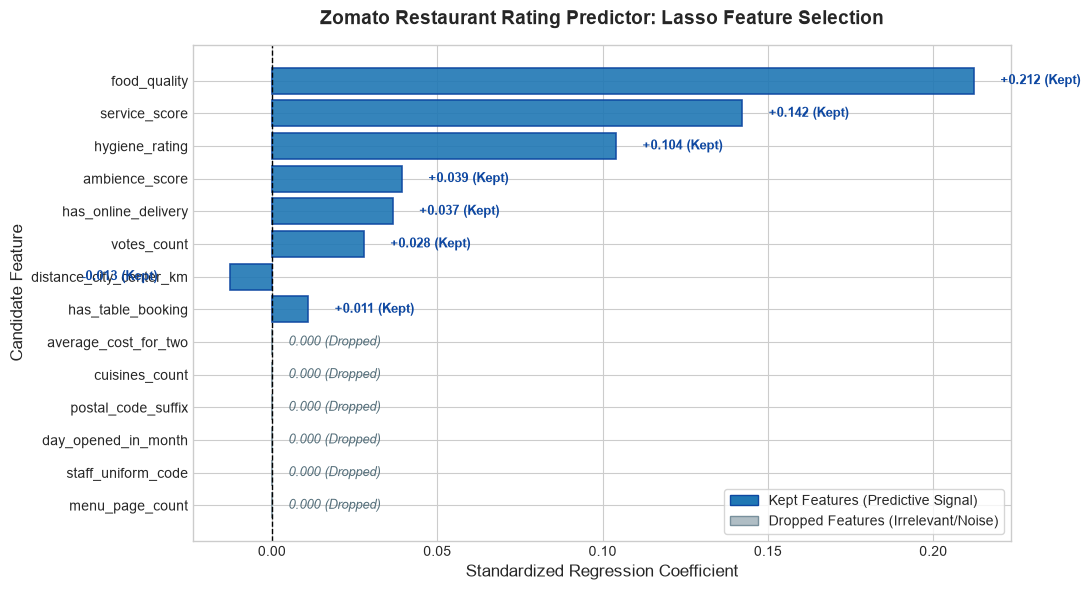

In [ ]:
# Visualization of Feature Selection Results
plt.figure(figsize=(11, 6))

colors = ['#1f77b4' if d == 'KEPT' else '#b0bec5' for d in zomato_coef_df['Decision']]
edgecolors = ['#0d47a1' if d == 'KEPT' else '#78909c' for d in zomato_coef_df['Decision']]

bars = plt.barh(
    zomato_coef_df['Feature'],
    zomato_coef_df['Coefficient'],
    color=colors,
    edgecolor=edgecolors,
    linewidth=1.2,
    alpha=0.9
)

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Zomato Restaurant Rating Predictor: Lasso Feature Selection', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Standardized Regression Coefficient', fontsize=12)
plt.ylabel('Candidate Feature', fontsize=12)
plt.gca().invert_yaxis()

# Annotate bars
for bar, decision, val in zip(bars, zomato_coef_df['Decision'], zomato_coef_df['Coefficient']):
    if decision == 'KEPT':
        offset = 0.008 if val >= 0 else -0.045
        plt.text(val + offset, bar.get_y() + bar.get_height()/2, f"{val:+.3f} (Kept)", 
                 va='center', fontsize=9, fontweight='bold', color='#0d47a1')
    else:
        plt.text(0.005, bar.get_y() + bar.get_height()/2, "0.000 (Dropped)", 
                 va='center', fontsize=9, fontstyle='italic', color='#546e7a')

# Legend
legend_elements = [
    Patch(facecolor='#1f77b4', edgecolor='#0d47a1', label='Kept Features (Predictive Signal)'),
    Patch(facecolor='#b0bec5', edgecolor='#78909c', label='Dropped Features (Irrelevant/Noise)')
]
plt.legend(handles=legend_elements, loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


### Business & Machine Learning Summary for Zomato Rating Predictor:
1. **Selected (Kept) Features**:
   - `food_quality`: The strongest single positive contributor to restaurant ratings.
   - `service_score` & `hygiene_rating`: Major operational factors that drive customer satisfaction.
   - `ambience_score`: Positive influence on overall dining experience.
   - `has_online_delivery` & `has_table_booking`: Modern consumer conveniences that boost ratings.
   - `votes_count`: Establishes social proof and restaurant popularity.
   - `distance_city_center_km`: Slightly negative coefficient reflecting accessibility preference.

2. **Eliminated (Dropped) Features**:
   - `postal_code_suffix`: Arbitrary administrative numbering with zero real signal.
   - `day_opened_in_month`: Calendar artifact with no bearing on dining experience.
   - `staff_uniform_code`: Arbitrary categorical noise.
   - `menu_page_count`: Unrelated format artifact zeroed out by Lasso.

3. **Production Benefit**:
   - By eliminating 4 uninformative features automatically, the feature dimension is reduced without manual heuristics, training and inference speed is improved, and the final model is significantly less prone to overfitting.
